# Recovery Score Analysis

## Part 1: Linear Regression Plan

For the first part of the analysis, we will fit a linear regression model with:

- **X variables:** age, gender, workout type, workout time of the day
- **Y variable:** recovery score

This section will include data preparation, encoding of categorical predictors, and model fitting to evaluate how these features relate to recovery score.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [26]:
df = pd.read_csv('../data/whoop_fitness_dataset_100k.csv')

# Replace NaN in workout_time_of_day with a meaningful category
df['workout_time_of_day'] = df['workout_time_of_day'].fillna('No_Workout')

# Categorical columns
categorical_onehot = ['gender', 'primary_sport', 'activity_type', 'workout_time_of_day']
ordinal_cols = ['fitness_level']

# Ordinal mapping for fitness level
fitness_order = [['Beginner', 'Intermediate', 'Advanced', 'Elite']]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_onehot),
        ('ordinal', OrdinalEncoder(categories=fitness_order), ordinal_cols)
    ],
    remainder='passthrough'   # keeps numeric columns like age, sleep_efficiency
)


In [27]:
X_cols = ['age',
          'gender',
          'fitness_level',
          'primary_sport',
          'activity_type',
          'workout_time_of_day']

y_col = 'recovery_score'
df[X_cols].head()


,age,gender,fitness_level,primary_sport,activity_type,workout_time_of_day
0,56,Female,Beginner,Weight Training,Rest Day,No_Workout
1,56,Female,Beginner,Weight Training,Weight Training,Evening
2,56,Female,Beginner,Weight Training,Rest Day,No_Workout
3,56,Female,Beginner,Weight Training,Rest Day,No_Workout
4,56,Female,Beginner,Weight Training,Weight Training,Evening


In [28]:
df[X_cols + [y_col]].info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  100000 non-null  int64  
 1   gender               100000 non-null  str    
 2   fitness_level        100000 non-null  str    
 3   primary_sport        100000 non-null  str    
 4   activity_type        100000 non-null  str    
 5   workout_time_of_day  100000 non-null  str    
 6   recovery_score       100000 non-null  float64
dtypes: float64(1), int64(1), str(5)
memory usage: 5.3 MB


In [29]:
print("Unique fitness_level values:")
print(df['fitness_level'].unique())
print("\nValue counts:")
print(df['fitness_level'].value_counts())

Unique fitness_level values:
<StringArray>
['Beginner', 'Elite', 'Intermediate', 'Advanced']
Length: 4, dtype: str

Value counts:
fitness_level
Intermediate    40702
Advanced        27447
Beginner        19065
Elite           12786
Name: count, dtype: int64


In [30]:


# -----------------------------
# 1. Select variables
# -----------------------------
X = df[X_cols]                  # independent variables
y = df['recovery_score']       # dependent variable

# -----------------------------
# 2. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Fit the model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# 4. Evaluate
# -----------------------------
r2 = model.score(X_test, y_test)
print("R² score:", r2)

# -----------------------------
# 5. Optional: coefficient + intercept
# -----------------------------
print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)


ValueError: could not convert string to float: 'Female'

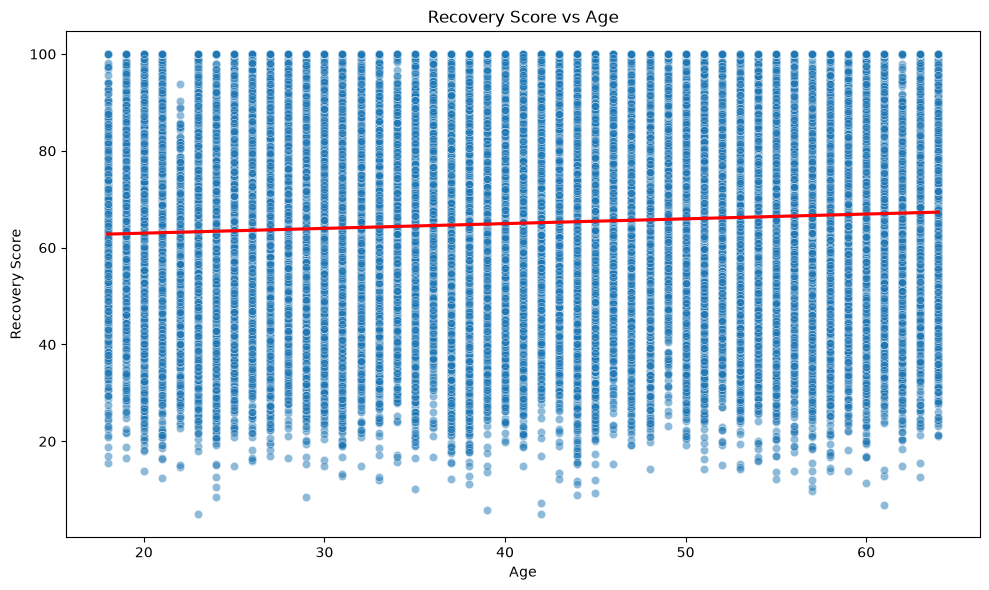

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='recovery_score', alpha=0.5)
sns.regplot(data=df, x='age', y='recovery_score', scatter=False, color='red', ci=None)
plt.title('Recovery Score vs Age')
plt.xlabel('Age')
plt.ylabel('Recovery Score')
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm


# -----------------------------
# 1. Select variables
# -----------------------------
X = df[X_cols]
y = df['recovery_score']

# -----------------------------
# 2. Add constant (required for OLS)
# -----------------------------
X = sm.add_constant(X)

# -----------------------------
# 3. Fit the model
# -----------------------------
model = sm.OLS(y, X).fit()

# -----------------------------
# 4. Show full regression summary
# -----------------------------
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         recovery_score   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     549.5
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          3.52e-121
Time:                        19:37:52   Log-Likelihood:            -4.2897e+05
No. Observations:              100000   AIC:                         8.579e+05
Df Residuals:                   99998   BIC:                         8.580e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.0208      0.184    331.647      0.0

In conclusion while age has a statistically significant, reliable effect on recovery scores, its low R² indicates that age alone cannot account for most of the variation, justifying the transition to a multivariate machine learning model to incorporate other critical predictors !


*LightGBMRegressor*


In [32]:
from lightgbm import LGBMRegressor
# -----------------------------
# 3. Build the LightGBM pipeline
# -----------------------------
lgbm_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42
    ))
])
# -----------------------------
# 4. Fit the model
# -----------------------------
lgbm_model.fit(X_train, y_train)

# -----------------------------
# 5. Evaluate performance
# -----------------------------
preds = lgbm_model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)

print("R² score:", r2)
print("MAE:", mae)
print("MSE:", mse)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005949 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 21
[LightGBM] [Info] Start training from score 65.118579


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


R² score: 0.21887613984278875
MAE: 12.659414858365757
MSE: 243.67674974016325
